In [1]:
from two_D_project import Two_D_test, Particle_config
import numpy as np
from matplotlib import pyplot as plt

In [2]:
np.random.seed(13) # We set a seed for reproductibility
N = 100
rho_target = 0.227
Length = np.sqrt(N / rho_target)  # Calculated from the reduced density

sigma_0 = 1.0  # Setting the hard core according to recommendation
sigma_1 = 2.5  # Same with the soft shoulder
epsilon = 1.0  # Set the energy to unit also
T_target = 0.1  # Target production temperature
cap = 100000  # Max potential instead of infinity

In [3]:
# Particle configuration is stored in a Particle_config object, which is then passed to the Two_D_test class for simulation.
pc = Particle_config(N=N, rho=rho_target, L=Length, sigma_0=sigma_0, sigma_1=sigma_1, epsilon=epsilon, T_target=T_target, cap=cap)
simulation = Two_D_test(pc)

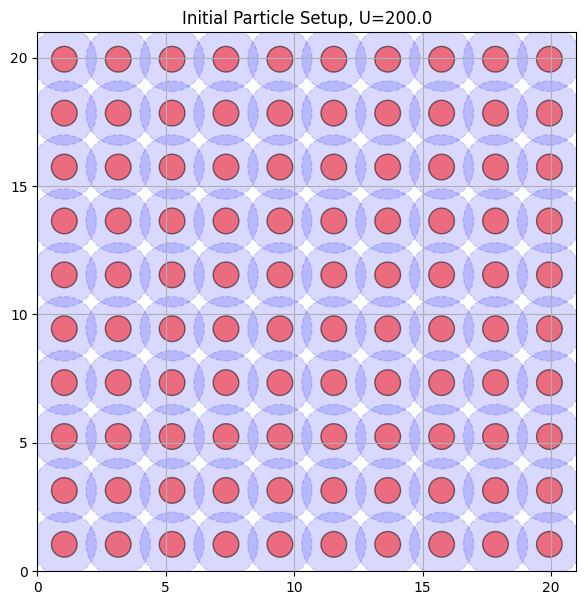

In [4]:
# Cold start on the orthogonal grid configuration
pc.cold_start_ort_grid_config()

# Or hot start
# pc.hot_start_config()

pc.visualize(title=f"Initial Particle Setup, U={pc.U_full()}")

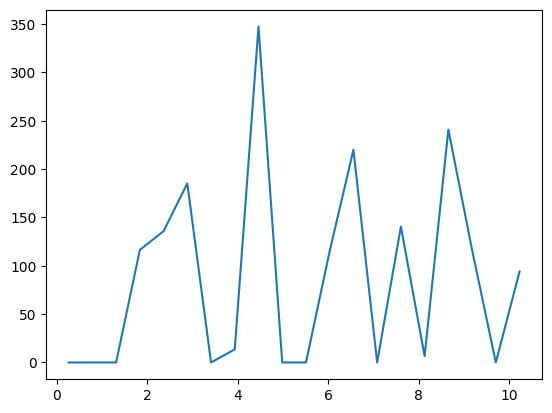

In [7]:
g, r = pc.average_radial_density(n_bins=20)
plt.plot(r,g)

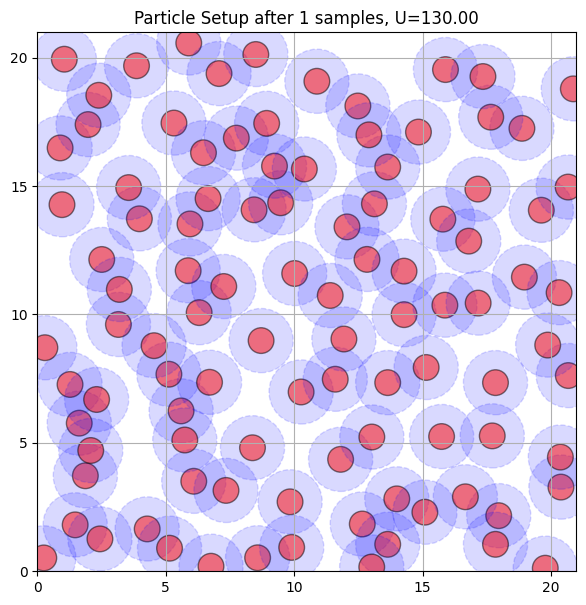

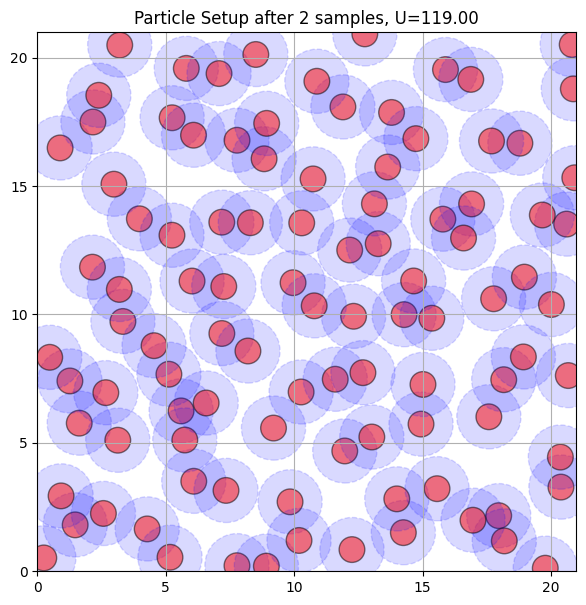

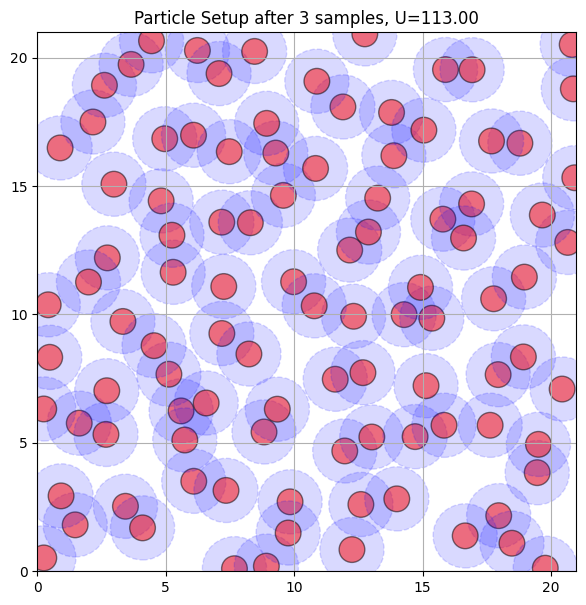

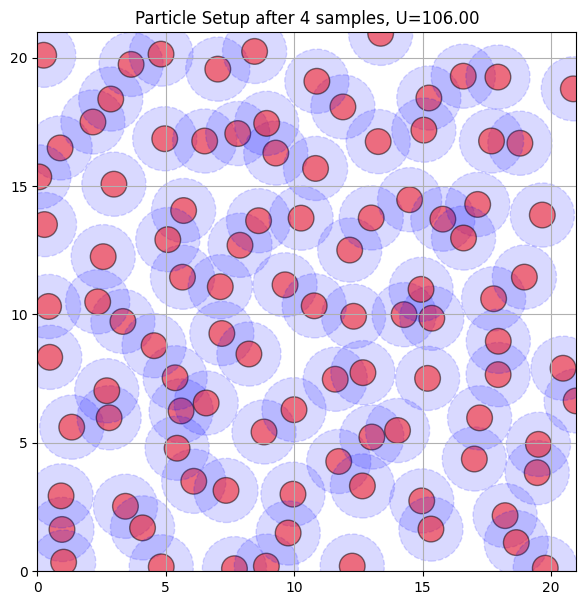

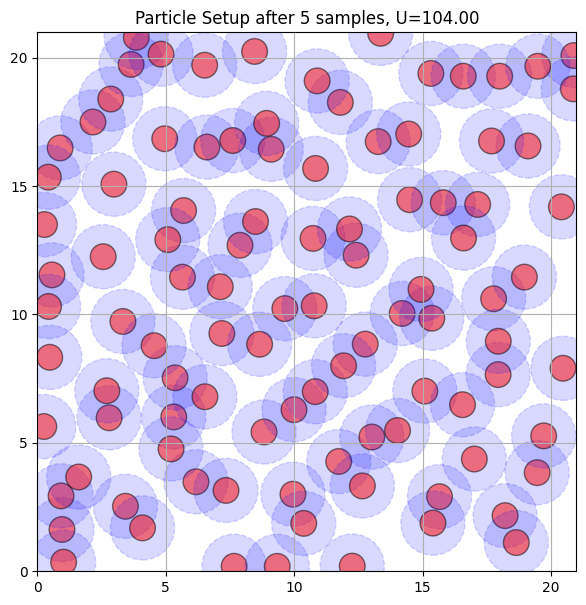

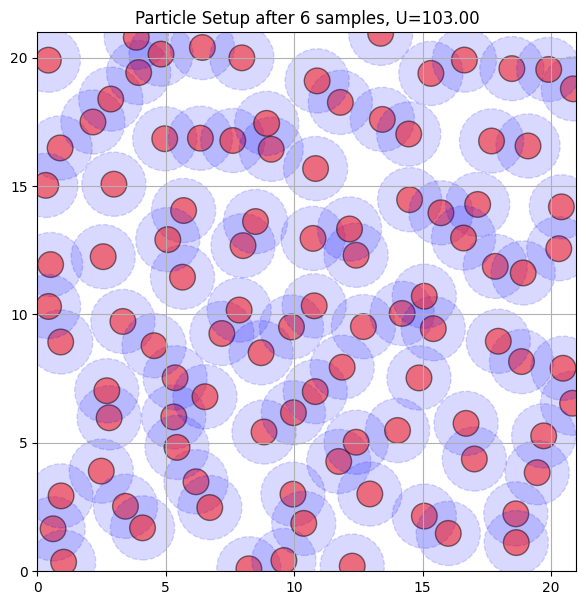

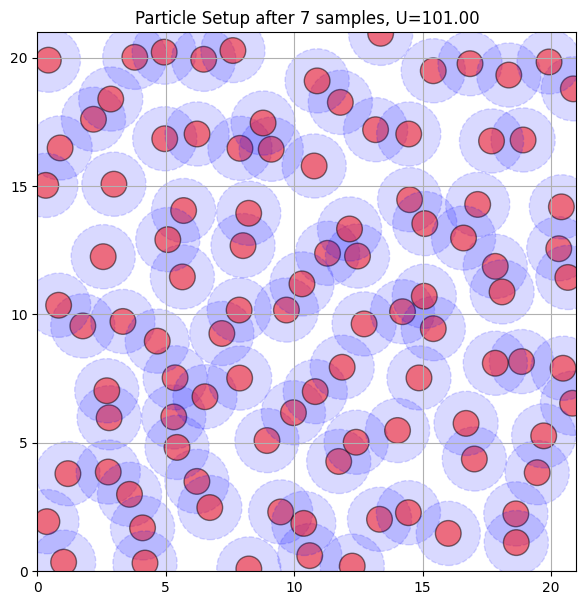

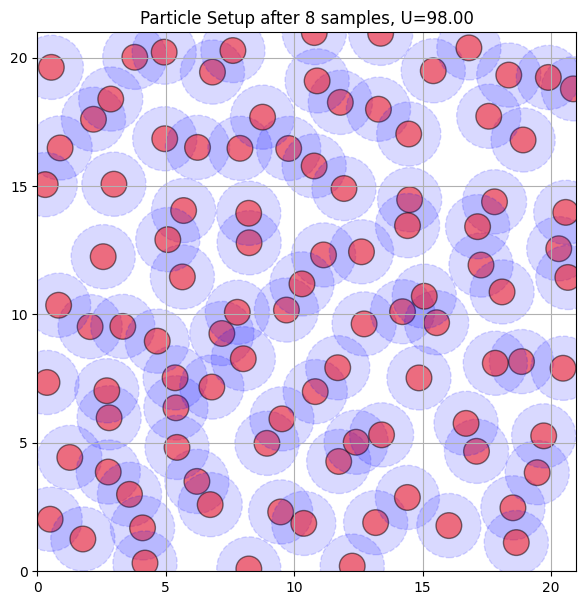

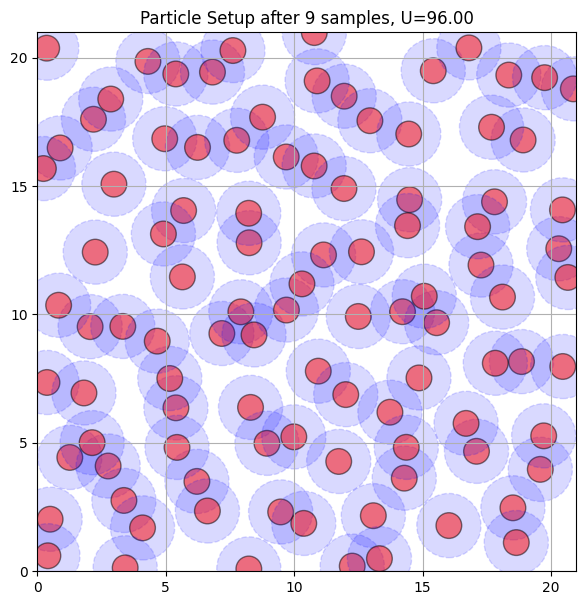

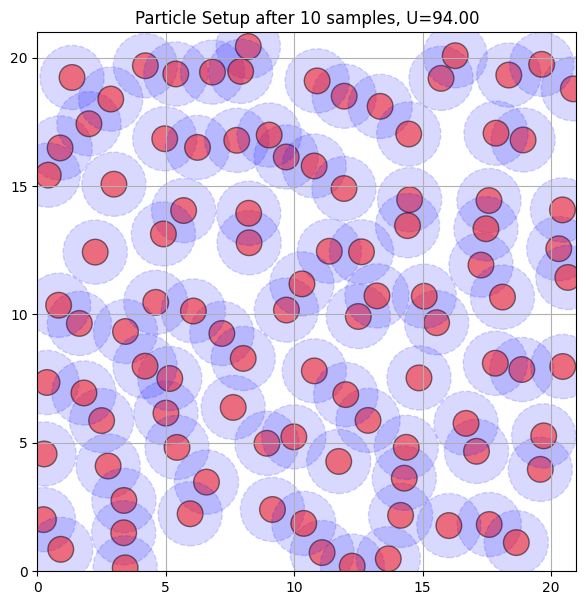

In [6]:
# n_iter    - the number of iterations of MCMC,
# n_samples - the number of samples evenly spaced in the iterations (the number of samples should be smaller than the number of iterations).,
# n_bins    - has no effect for now (will affect the radial density calculation).
# it is better to make n_iter a multiple of n_samples (actual n_iter = (n_iter // n_samples) * n_samples))
simulation.run_simulation(n_iter=5000, n_samples=10, n_bins=10, draw=True)